### This will be the title block

#### Dependency import

In [1]:
print("Hello, World!")

Hello, World!


In [2]:
import numpy as np
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import torch

In [3]:
torch.__version__

'2.13.0+cpu'

#### Import Data Set

In [4]:
path = kagglehub.dataset_download("natezhang123/social-anxiety-dataset")
print(f"Path to dataset files: {path}")
anxiety_file = os.path.join(path, 'enhanced_anxiety_dataset.csv')
anxiety = pd.read_csv(anxiety_file)

Path to dataset files: C:\Users\cmurr\.cache\kagglehub\datasets\natezhang123\social-anxiety-dataset\versions\2


In [5]:
print(f"anxiety.columns: {anxiety.columns}")
print(f"anxiety.shape: {anxiety.shape}")

anxiety.columns: Index(['Age', 'Gender', 'Occupation', 'Sleep Hours',
       'Physical Activity (hrs/week)', 'Caffeine Intake (mg/day)',
       'Alcohol Consumption (drinks/week)', 'Smoking',
       'Family History of Anxiety', 'Stress Level (1-10)', 'Heart Rate (bpm)',
       'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Dizziness',
       'Medication', 'Therapy Sessions (per month)', 'Recent Major Life Event',
       'Diet Quality (1-10)', 'Anxiety Level (1-10)'],
      dtype='str')
anxiety.shape: (11000, 19)


In [6]:
anxiety.info()

<class 'pandas.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Gender                             11000 non-null  str    
 2   Occupation                         11000 non-null  str    
 3   Sleep Hours                        11000 non-null  float64
 4   Physical Activity (hrs/week)       11000 non-null  float64
 5   Caffeine Intake (mg/day)           11000 non-null  int64  
 6   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 7   Smoking                            11000 non-null  str    
 8   Family History of Anxiety          11000 non-null  str    
 9   Stress Level (1-10)                11000 non-null  int64  
 10  Heart Rate (bpm)                   11000 non-null  int64  
 11  Breathing Rate (breaths/min)       11000 non-null  int64  
 12  S

In [7]:
anxiety.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,11000.0,40.241727,13.236140,18.0,29.0,40.0,51.0,64.0
Sleep Hours,11000.0,6.650691,1.227509,2.3,5.9,6.7,7.5,11.3
Physical Activity (hrs/week),11000.0,2.942136,1.827825,0.0,1.5,2.8,4.2,10.1
Caffeine Intake (mg/day),11000.0,286.090000,144.813157,0.0,172.0,273.0,382.0,599.0
Alcohol Consumption (drinks/week),11000.0,9.701636,5.689713,0.0,5.0,10.0,15.0,19.0
Stress Level (1-10),11000.0,5.856364,2.927202,1.0,3.0,6.0,8.0,10.0
Heart Rate (bpm),11000.0,90.916000,17.325721,60.0,76.0,92.0,106.0,119.0
Breathing Rate (breaths/min),11000.0,20.957545,5.160107,12.0,17.0,21.0,25.0,29.0
Sweating Level (1-5),11000.0,3.080636,1.398877,1.0,2.0,3.0,4.0,5.0
Therapy Sessions (per month),11000.0,2.427818,2.183106,0.0,1.0,2.0,4.0,12.0


In [8]:
anxiety.shape

(11000, 19)

#### Data Prep and EDA

In [9]:
# One hot encoding of categorical / non-numeric variable
anxiety_dummies = pd.get_dummies(anxiety, drop_first=True, dtype=int)

In [10]:
anxiety_dummies.head()

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Therapy Sessions (per month),...,Occupation_Nurse,Occupation_Other,Occupation_Scientist,Occupation_Student,Occupation_Teacher,Smoking_Yes,Family History of Anxiety_Yes,Dizziness_Yes,Medication_Yes,Recent Major Life Event_Yes
0,29,6.0,2.7,181,10,10,114,14,4,3,...,0,0,0,0,0,1,0,0,1,1
1,46,6.2,5.7,200,8,1,62,23,2,2,...,1,0,0,0,0,1,1,1,0,0
2,64,5.0,3.7,117,4,1,91,28,3,1,...,0,1,0,0,0,0,1,0,0,1
3,20,5.8,2.8,360,6,4,86,17,3,0,...,0,0,1,0,0,1,0,0,0,0
4,49,8.2,2.3,247,4,1,98,19,4,1,...,0,1,0,0,0,1,0,1,1,0


In [11]:
anxiety_dummies.shape

(11000, 31)

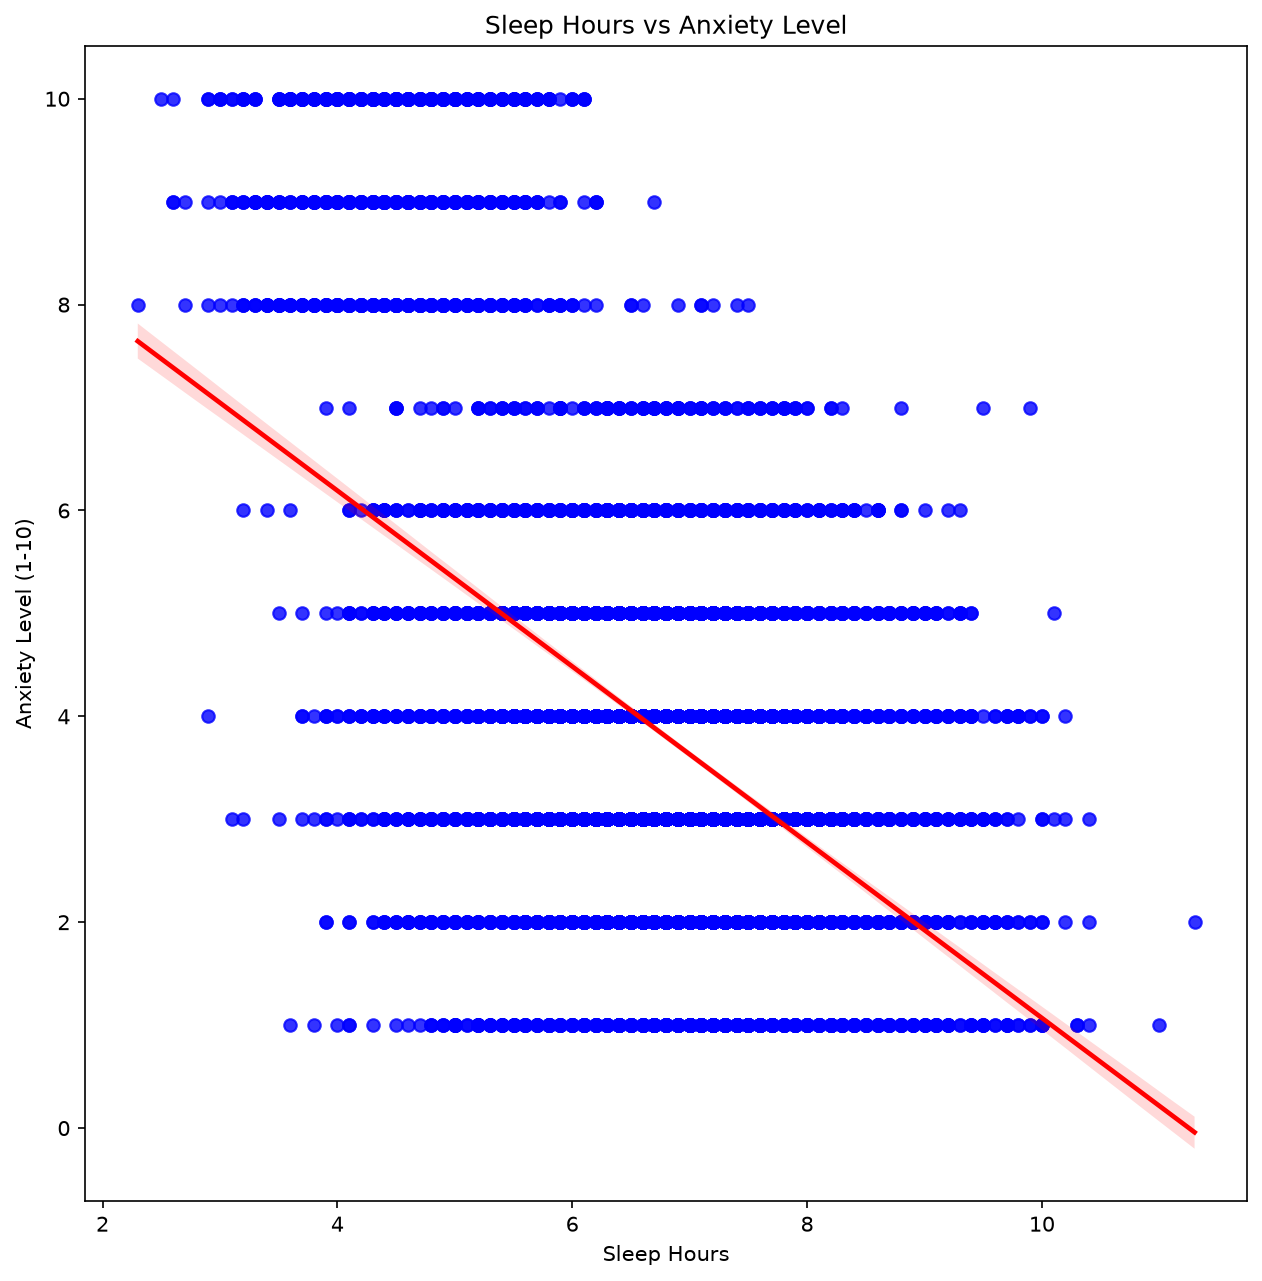

In [12]:
plt.figure(figsize=(10,10), dpi=150)
# Base chart
sns.regplot(x="Sleep Hours", y="Anxiety Level (1-10)", data=anxiety_dummies, color='blue', line_kws={'color': 'red'})
# Add title
plt.title('Sleep Hours vs Anxiety Level')  ;
